In [7]:
from netCDF4 import Dataset
import xarray as xr
import numpy as np
import matplotlib.pylab as plt
from glob import glob
from mpl_toolkits.basemap import Basemap
import sys
sys.path.append("/Users/iufarias/BC_eddies/")
import utilities as util

plt.rcParams['font.size']=18
plt.rcParams['font.sans-serif']='Arial'
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['font.weight']='bold'

In [8]:
def figplot(sizeh,sizev,lnmn,lnmx,ltmn,ltmx,contcolor='#fecf78',alpha=1):

    p=plt.figure(figsize=(sizeh,sizev))
    lbs=[True, False,False,True]
    C = Basemap(llcrnrlon=lnmn+2,llcrnrlat=ltmn,urcrnrlat=ltmx,urcrnrlon=lnmx,resolution='h',projection='cyl')

    C.drawcoastlines(linewidth=1);
    C.fillcontinents(color='#fecf78',alpha=alpha)
    C.drawstates(linewidth=0.5)
    C.drawmeridians(np.arange(lnmn,lnmx,4),labels=lbs,zorder=100,linewidth=0.1)
    C.drawparallels(np.arange(ltmn,ltmx,4),labels=lbs,zorder=101,linewidth=0.1)
    
    return C

In [9]:
path='/Users/iufarias/Documents/META3.1exp/altdata/'
# fname=glob(path +'adcp_OEII/*'); fname.sort();
fname=glob(path +'dt_global*'); fname.sort();

var=xr.open_mfdataset(fname)

In [24]:
var=var.assign_coords(longitude=('longitude',var.longitude.data-360))

In [25]:
ME=var.err.mean(axis=0) # mean
STD=var.err.std(axis=0) #std

In [26]:

ltmn=-29;ltmx=-14;lnmn=-52;lnmx=-35.

topo=Dataset('/Users/iufarias/Documents/META3.1exp/bat/etopo1_bedrock.nc')
xb=topo['lon'][:];yb=topo['lat'][:];zb=topo['Band1'][:];
zb=util.smoo(zb,20)
xxb,yyb=np.meshgrid(xb,yb);

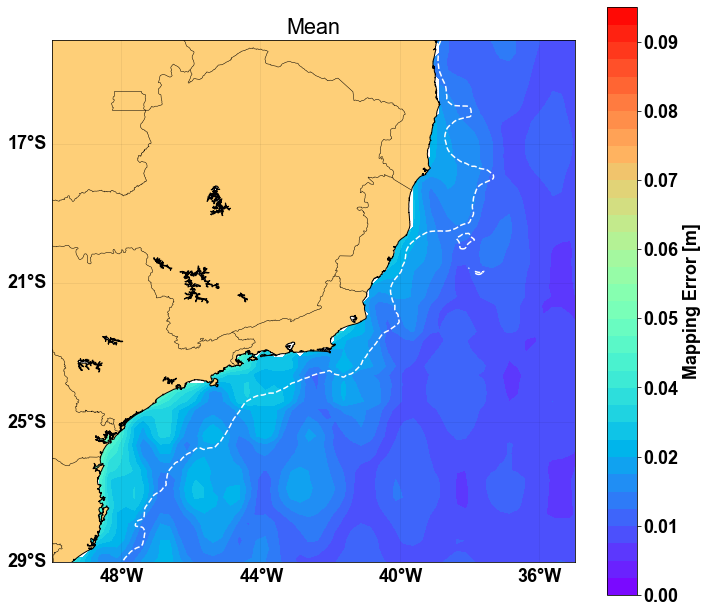

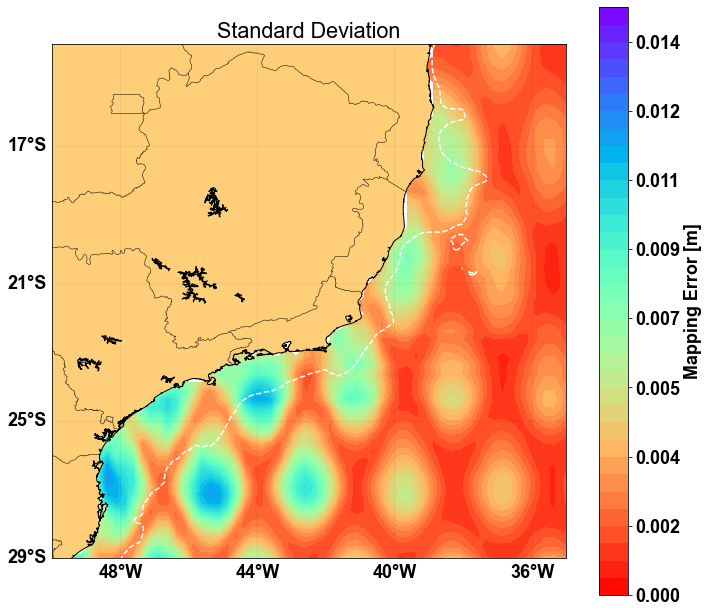

In [32]:
C=figplot(sizeh=10.26,sizev=8.96,lnmn=lnmn,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx)
plt.contour(xxb,yyb,zb,colors='white',alpha=1,levels=[-200,np.inf])

cc=plt.contourf(ME.longitude,ME.latitude,ME,cmap='rainbow',levels=np.linspace(0,0.1,35))
cbar=plt.colorbar(cc,format='%.2f')
cbar.set_label('Mapping Error [m]',fontweight='bold')
plt.title('Mean')

plt.tight_layout()
plt.savefig('/Users/iufarias/Documents/META3.1exp/figs/mean_mapping_error.png')


C1=figplot(sizeh=10.26,sizev=8.96,lnmn=lnmn,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx)

plt.contour(xxb,yyb,zb,colors='white',alpha=1,levels=[-200,np.inf])
plt.title('Standard Deviation')
cc1=plt.contourf(STD.longitude,STD.latitude,STD,cmap='rainbow_r',levels=np.linspace(0,0.015,35))
cbar1=plt.colorbar(cc1,format='%.3f')
cbar1.set_label('Mapping Error [m]',fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/iufarias/Documents/META3.1exp/figs/STD_mapping_error.png')


